# Spike Statistics of Simulated Neurons

In [1]:
import random
import numpy as np
from matplotlib import pyplot as plt
from scipy.stats import poisson
import quantities as pq
from elephant.spike_train_generation import StationaryPoissonProcess, NonStationaryPoissonProcess
from elephant.statistics import mean_firing_rate, instantaneous_rate, isi, cv
random.seed(100)
%matplotlib inline

## 1 Working whith Physical Quantities

| Code | Description |
|------------------------------------|------------------------------------|
| freq = `2 * pq.Hz` | Define a quantity of 2 Hertz and assign it to the variable `freq` |
| time = `2500 * pq.ms` | Define a quantity of 2500 milliseconds and assign it to the variable `time` |
| `time.units` | Get the unit of `time` |
| `time.magnitude` | Get the magnitude of `time` |

<span class="theorem-title">**Exercise 1**</span> Create a variable
called `firing_rate` and assign it the value **5 Hertz**.

In [2]:
firing_rate = 5 * pq.Hz

<span class="theorem-title">**Exercise 2**</span> Create a variable
called `t_start` and assign it the value **100 milliseconds**.

In [3]:
t_start = 100 * pq.ms

<span class="theorem-title">**Exercise 3**</span> Create a variable
called `t_stop` and assign it the value **3 seconds**

In [4]:
t_stop = 3 * pq.s

<span class="theorem-title">**Exercise 4**</span> Subtract t_start from
t_stop and assign the result to a variable called `duration`. Print the
magnitude and unit of that variable.

In [5]:
duration = t_stop - t_start
print(duration.magnitude, duration.units)

2.9 1.0 s

<span class="theorem-title">**Exercise 5**</span> Multiply the variable
`duration` by `firing_rate`. Simplify the unit of the result

In [6]:
x = duration * firing_rate
print(x.simplified)

14.5 dimensionless

<span class="theorem-title">**Exercise 6**</span> Try adding the
variables `firing_rate` and `duration`. What error message do you
observe?

In [7]:
firing_rate+duration

## 2 Simulating and Visualizing Spike Trains

| Code | Description |
|------------------------------------|------------------------------------|
| `neuron = StationaryPoissonProcess(rate=2*pq.Hz, t_start=0*pq.s, t_stop=3*pq.s)` | Define a stationary Poisson Process with a mean `rate` of 2 Hz that starts at 0s and ends at 3s |
| `st` = neuron.generate_spiketrain()`| Generate a spike train from a Poisson`neuron`and assign the returned`SpikeTrain`object to the variable`st`| |`st.times`| Get the spike times of the`SpikeTrain`object stored in the varable`st`| |`sts`= neuron.generate_n_spiketrains(5)` | Generate 5 spike trains from a Poisson `neuron` and assign the returned list of `SpikeTrain` objects to the variable `sts` |

<span class="theorem-title">**Exercise 7**</span> Simulate a
`StationaryPoissonProcess` with a `rate` of 5 Hz that starts at 1 s and
ends at 2.5 s and assign it to a variable called `neuron1`.

In [8]:
neuron1 = StationaryPoissonProcess(rate=5*pq.Hz, t_start=1*pq.s, t_stop=2.5*pq.s)

<span class="theorem-title">**Exercise 8**</span> Generate a spike train
from `neuron1` and assign it to the variable `st1` and print the spike
`.times`.

In [9]:
st1 = neuron1.generate_spiketrain()
print(st1.times)

[1.32732676 1.44434559 2.08087284 2.13244985 2.33485738 2.36744641] s

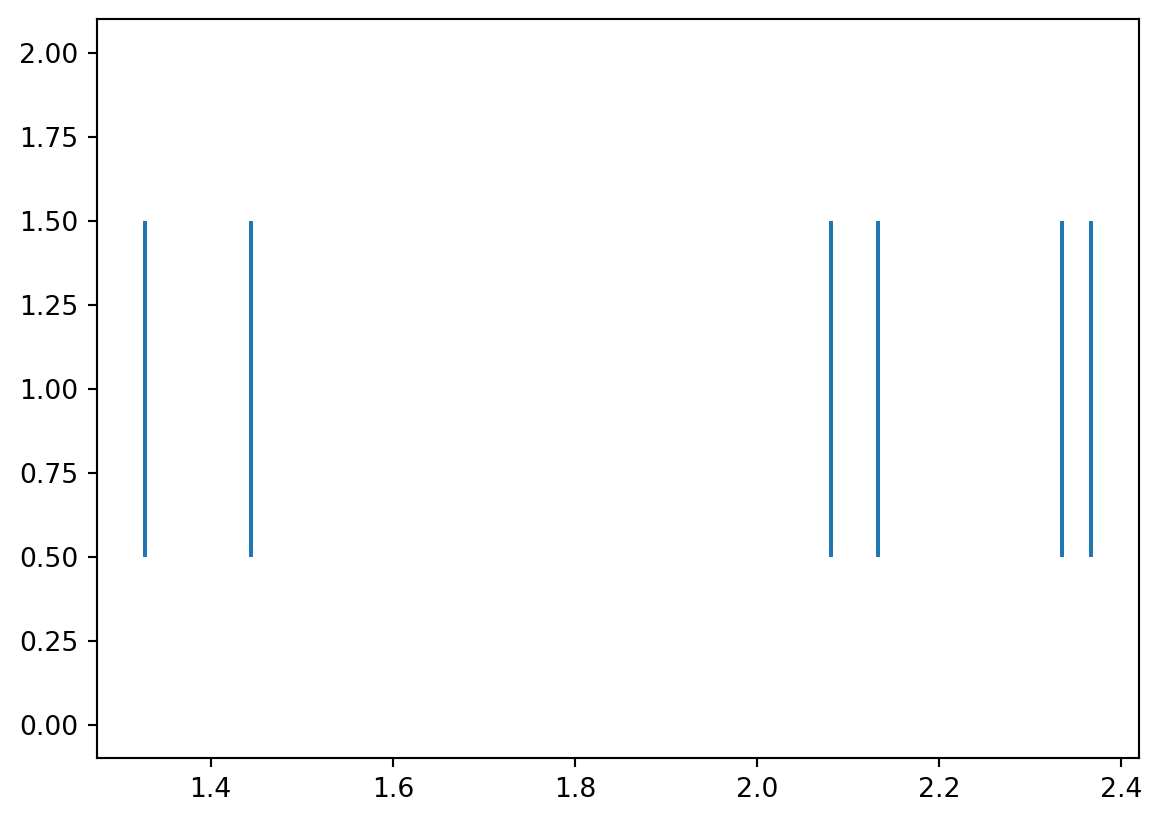

In [10]:
plt.eventplot(st1.times)

## 3 Estimating Firing Rates

<span class="theorem-title">**Exercise 9**</span> Simulate a
`StationaryPoissonProcess` with a `rate` of 0.5 Hz that starts at 0 s
and ends at 2 s and assign it to a variable called `neuron2`. Generate
1000 spike trains from `neuron2` and assign them to a variable called
`sts2`.

In [11]:
neuron2 = StationaryPoissonProcess(rate=0.5*pq.Hz, t_start=0*pq.s, t_stop=2*pq.s)
sts2 = neuron2.generate_n_spiketrains(100)

<span class="theorem-title">**Exercise 10**</span> Compute the number of
spikes (i.e. the `len()` of each spike train) and store them in a list
called `n_spikes`. Then, plot a histogram of `n_spikes`.

(array([26.,  0., 45.,  0.,  0., 22.,  0.,  6.,  0.,  1.]),
 array([0. , 0.4, 0.8, 1.2, 1.6, 2. , 2.4, 2.8, 3.2, 3.6, 4. ]),
 <BarContainer object of 10 artists>)

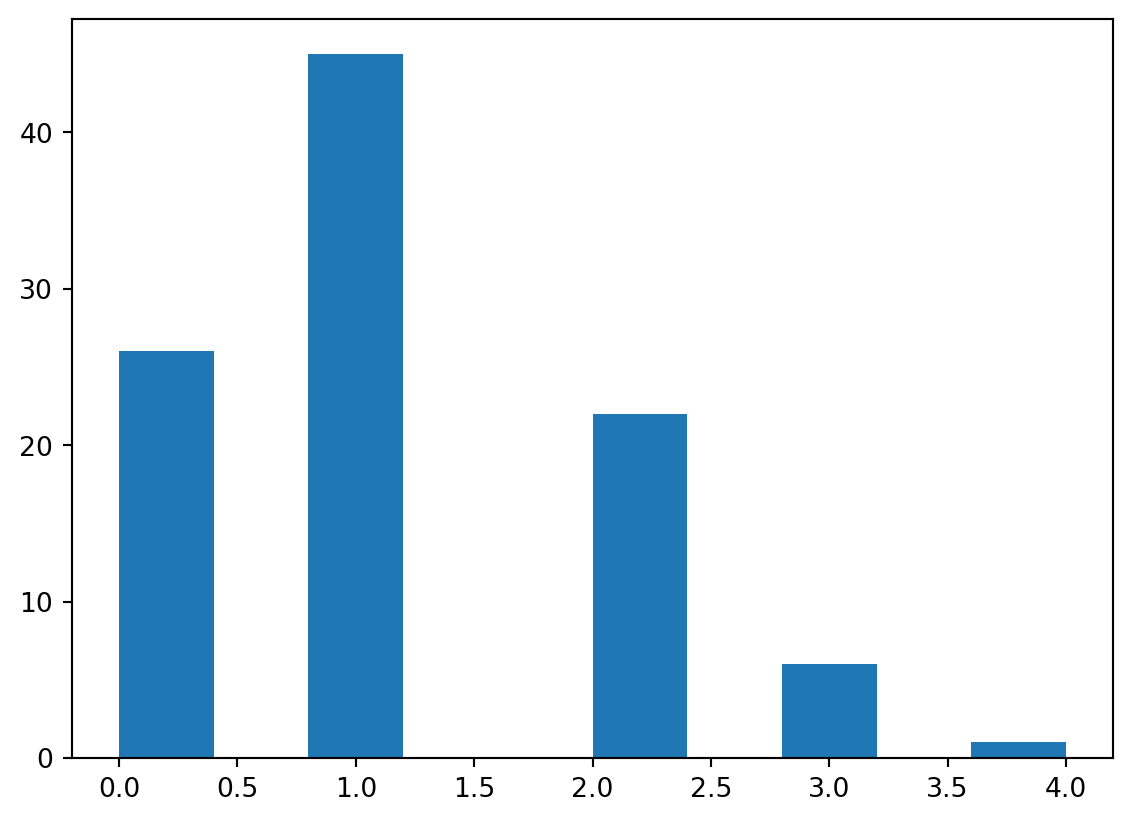

In [12]:
n_spikes = [len(st) for st in sts2]
plt.hist(n_spikes)

<span class="theorem-title">**Exercise 11**</span>

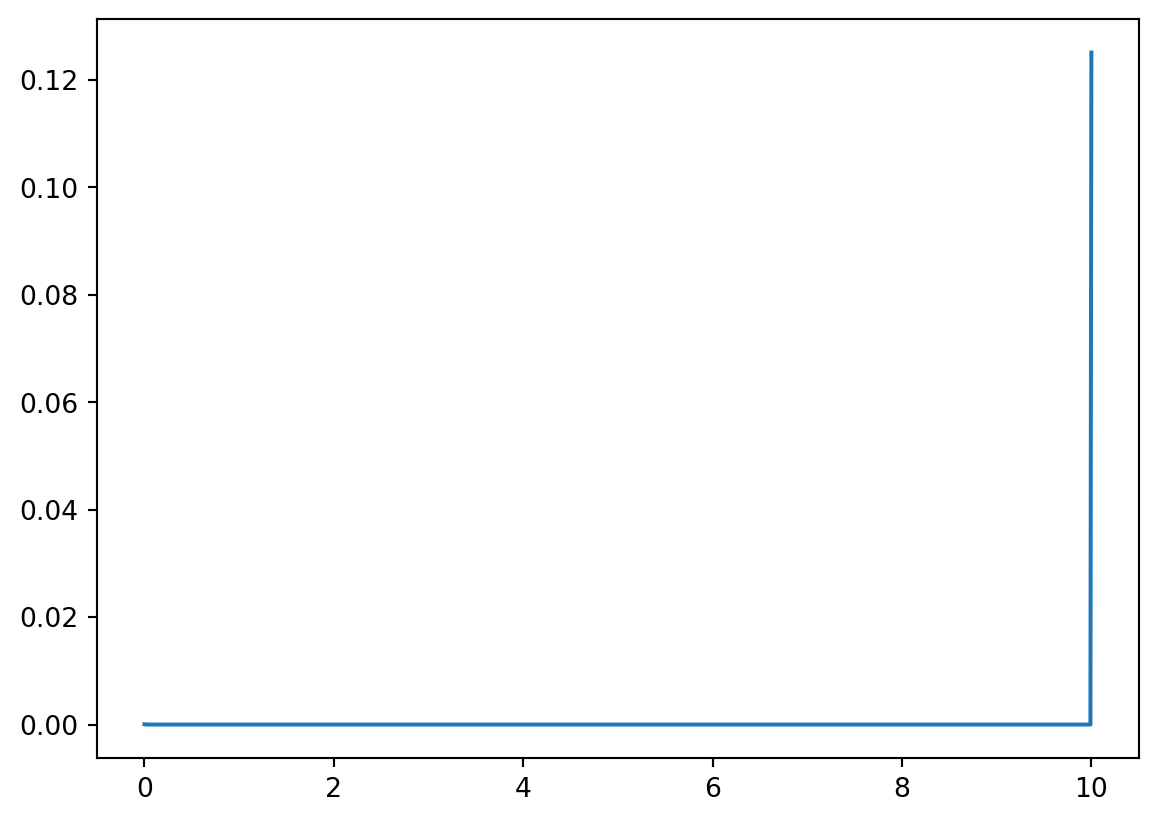

In [13]:
mu=0.5
x = np.linspace(0, 10, 1000)
plt.plot(x, poisson.pmf(x, 10))

## 4 Inter-Spike Intervals and the Coefficient of Variation

## 5 Non-Stationary Poisson Processes